# Machine Learning on Embeddings for Epitope Prediction

The goal of this notebook is to put together a basic machine learning pipeline that can make epitope predictions using embeddings from AF3 and ESM

## Environment:

This notebook will run with the 'envs/env.yaml` environment (epident-experiments)

## Bepipred 3 dataset

- job_name: unique identifier for protein, comes from hash of seq
- seq: amino acid sequence of protein
- train: boolean indicating if seq is part of train set
- epitope_boolmask: boolean array the same length as seq indiciating if the AA at that position is an epitope residue
- raw_protein_id: original ID assigned to protein in BP3C50ID set
- RSA: relative solvent accessiblity of the protein at each AA, calculated by FreeSASA
- SA: absolute solvent accessibility of the protein at each AA, calculated by FreeSASA

In [38]:
# --- Imports ---

import polars as pl
import pandas as pd
import pickle
from mdaf3.AF3OutputParser import AF3Output
from pathlib import Path
import torch
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from plotnine import *
theme_set(theme_classic())

# --- Bepipred3 Data ---

bp3 = pl.read_parquet("../data/bp3c50id/bp3c50id.rsa.parquet")
bp3 = bp3.rename({"test" : "train"})
print(bp3)

shape: (358, 7)
┌───────────────┬──────────────┬───────┬──────────────┬──────────────┬──────────────┬──────────────┐
│ job_name      ┆ seq          ┆ train ┆ epitope_bool ┆ raw_protein_ ┆ RSA          ┆ SA           │
│ ---           ┆ ---          ┆ ---   ┆ mask         ┆ id           ┆ ---          ┆ ---          │
│ str           ┆ str          ┆ bool  ┆ ---          ┆ ---          ┆ list[f64]    ┆ list[f64]    │
│               ┆              ┆       ┆ list[bool]   ┆ str          ┆              ┆              │
╞═══════════════╪══════════════╪═══════╪══════════════╪══════════════╪══════════════╪══════════════╡
│ bf2a62534941c ┆ LIQTPSSLLVQT ┆ true  ┆ [false,      ┆ 3b9k_B       ┆ [0.205823,   ┆ [36.957627,  │
│ f895971e1daa3 ┆ NHTAKMSCEVKS ┆       ┆ false, …     ┆              ┆ 0.471213, …  ┆ 82.806331, … │
│ 3a46…         ┆ ISKLTS…      ┆       ┆ false]       ┆              ┆ 1.00154…     ┆ 152.2…       │
│ d4febd28417e8 ┆ GNVDLVFLFDGS ┆ true  ┆ [false,      ┆ 3hi6_A       ┆ [0.8

## Getting structural embeddings for a protein


In [2]:
# --- AF3 Embeddings ---

INF_DIR = Path("../data/bp3c50id/inference")
sample_job_name = bp3.select("job_name")[0].item()
af3_output = AF3Output(INF_DIR / sample_job_name)

af3_single_embed = af3_output.get_single_embeddings()
af3_pairwise_embed = af3_output.get_pair_embeddings()

#af3_single_embed
#af3_pairwise_embed

## Getting LM embeddings for a protein


In [3]:
# --- ESM Embeddings ---

ESM_ENCODING_DIR = Path("/tgen_labs/altin/esm_encodings")
esm_2_embed = torch.load(ESM_ENCODING_DIR / (sample_job_name + ".pt")).tolist()

if "esm_emb" not in bp3.columns:
    esm_embeddings = []
    for job_num in range(bp3.shape[0]):
        job_name = bp3.select("job_name")[job_num].item()
        esm_embeddings.append(torch.load(ESM_ENCODING_DIR / (job_name + ".pt")))
    esm_emb = pl.Series("esm_emb", esm_embeddings)
    bp3.insert_column(0, esm_emb)
    bp3 = bp3.drop(['job_name', "raw_protein_id", 'SA'])

if "train_boolmask" not in bp3:
    train_boolmask = []
    for (esm_emb, seq, train, epitope_boolmask, rsa) in bp3.iter_rows():
        train_bools = []
        for num in range(len(seq)):
            train_bools.append(train)
        train_boolmask.append(train_bools)
    train_boolmask = pl.Series("train_boolmask", train_boolmask)
    bp3.insert_column(2, train_boolmask)
    bp3 = bp3.drop(['train'])
    
print(bp3)


shape: (358, 5)
┌─────────────────────┬────────────────────┬────────────────────┬────────────────────┬─────────────┐
│ esm_emb             ┆ seq                ┆ train_boolmask     ┆ epitope_boolmask   ┆ RSA         │
│ ---                 ┆ ---                ┆ ---                ┆ ---                ┆ ---         │
│ object              ┆ str                ┆ list[bool]         ┆ list[bool]         ┆ list[f64]   │
╞═════════════════════╪════════════════════╪════════════════════╪════════════════════╪═════════════╡
│ tensor([[-7.9217e-0 ┆ LIQTPSSLLVQTNHTAKM ┆ [true, true, …     ┆ [false, false, …   ┆ [0.205823,  │
│ 2, -8.2230e…        ┆ SCEVKSISKLTS…      ┆ true]              ┆ false]             ┆ 0.471213, … │
│                     ┆                    ┆                    ┆                    ┆ 1.00154…    │
│ tensor([[           ┆ GNVDLVFLFDGSMSLQPD ┆ [true, true, …     ┆ [false, false, …   ┆ [0.840245,  │
│ 2.8654e-01,         ┆ EFQKILDFMKDV…      ┆ true]              ┆ false]   

In [ ]:
# --- Transform to Per-Residue Basis ---
 
embs = []
residues = []
train_bools = []
epitope_bools = []
rsa_vals = []
for (esm_emb, seq, train_boolmask, epitope_boolmask, rsa) in bp3.iter_rows():
    embs.extend(esm_emb.tolist())
    residues.extend(seq)
    train_bools.extend(train_boolmask)
    epitope_bools.extend(epitope_boolmask)
    rsa_vals.extend(rsa)

data = {
    "embeddings" : embs,
    "residues" : residues,
    "train_bools" : train_bools,
    "epitope_bools" : epitope_bools,
    "rsa_vals" : rsa_vals
}

bp3_res = pl.DataFrame(data)
bp3_res


embeddings,residues,train_bools,epitope_bools,rsa_vals
list[f64],str,bool,bool,f64
"[-0.079217, -0.08223, … 117.0]","""L""",true,false,0.205823
"[0.271906, 0.131599, … 117.0]","""I""",true,false,0.471213
"[0.075211, -0.124738, … 117.0]","""Q""",true,false,0.046812
"[0.033206, 0.13658, … 117.0]","""T""",true,false,0.437416
"[-0.153488, 0.178101, … 117.0]","""P""",true,false,0.312792
…,…,…,…,…
"[-0.102616, 0.023357, … 47.0]","""V""",false,false,0.09529
"[0.006365, -0.054578, … 47.0]","""Q""",false,false,0.559269
"[-0.021138, 0.060409, … 47.0]","""K""",false,false,0.883928


In [ ]:
# --- Extract N Most Informative Features of Embedding ---

# emb_var 1280 : 81 median diff
# emb_var 1280 : 1.13 median diff
# emb_var 1280 : 0.37 median diff



num_emb_vars = bp3_res.select("embeddings")[0].item().shape[0]

med_diff = []
for var in range(num_emb_vars):
    var_epi = []
    var_nepi = []
    for (embedding, residue, train_bool, epitope_bool, rsa) in bp3_res.iter_rows():
        if epitope_bool == True:
            var_epi.append(embedding[var])
        else:
            var_nepi.append(embedding[var])
    med_diff.append(np.median(var_nepi) - np.median(var_epi))


In [22]:
print(len(med_diff))
n_features = 100
indexed_list = [(value, index) for index, value in enumerate(med_diff)]
sorted_indexed_list = sorted(indexed_list, key=lambda x: x[0], reverse=True)
largest_10_indices = [index for value, index in sorted_indexed_list[:n_features]]
print(sorted_indexed_list)

1281
[(np.float64(81.0), 1280), (np.float64(1.130703330039978), 234), (np.float64(0.3712773323059082), 1160), (np.float64(0.045004742220044136), 839), (np.float64(0.044218819588422775), 553), (np.float64(0.04032979533076286), 696), (np.float64(0.03747392725199461), 414), (np.float64(0.03660698514431715), 1251), (np.float64(0.03643316403031349), 600), (np.float64(0.0351506844162941), 381), (np.float64(0.034491033758968115), 756), (np.float64(0.033380577340722084), 300), (np.float64(0.03337776567786932), 1014), (np.float64(0.03284870833158493), 1186), (np.float64(0.03240643069148064), 855), (np.float64(0.032072730362415314), 608), (np.float64(0.031966139416908845), 86), (np.float64(0.031056914827786386), 396), (np.float64(0.030288565903902054), 655), (np.float64(0.030203919857740402), 166), (np.float64(0.030178461922332644), 423), (np.float64(0.029451459646224976), 809), (np.float64(0.028364425525069237), 77), (np.float64(0.02815424744039774), 249), (np.float64(0.028020352125167847), 145

In [24]:
with open('best_embedding_vars.pkl', 'wb') as f:
        pickle.dump(sorted_indexed_list, f)


In [26]:
emb_1280 = []
emb_234 = []
emb_1160 = []
for (embedding, residue, train_bool, epitope_bool, rsa) in bp3_res.iter_rows():
    emb_1280.append(embedding[1280])
    emb_234.append(embedding[234])
    emb_1160.append(embedding[1160])

bp3_res.insert_column(0, pl.Series("emb_1280", emb_1280))
bp3_res.insert_column(0, pl.Series("emb_234", emb_234))
bp3_res.insert_column(0, pl.Series("emb_1160", emb_1160))


emb_1160,emb_234,emb_1280,embeddings,residues,train_bools,epitope_bools,rsa_vals
f64,f64,f64,list[f64],str,bool,bool,f64
-5.638327,-0.626679,117.0,"[-0.079217, -0.08223, … 117.0]","""L""",true,false,0.205823
-7.059569,-2.33806,117.0,"[0.271906, 0.131599, … 117.0]","""I""",true,false,0.471213
-3.455206,0.347305,117.0,"[0.075211, -0.124738, … 117.0]","""Q""",true,false,0.046812
-5.985601,-1.758423,117.0,"[0.033206, 0.13658, … 117.0]","""T""",true,false,0.437416
-4.628117,-0.632118,117.0,"[-0.153488, 0.178101, … 117.0]","""P""",true,false,0.312792
…,…,…,…,…,…,…,…
-8.687856,-2.586185,47.0,"[-0.102616, 0.023357, … 47.0]","""V""",false,false,0.09529
-8.632407,-3.705801,47.0,"[0.006365, -0.054578, … 47.0]","""Q""",false,false,0.559269
-8.433228,-4.293248,47.0,"[-0.021138, 0.060409, … 47.0]","""K""",false,false,0.883928


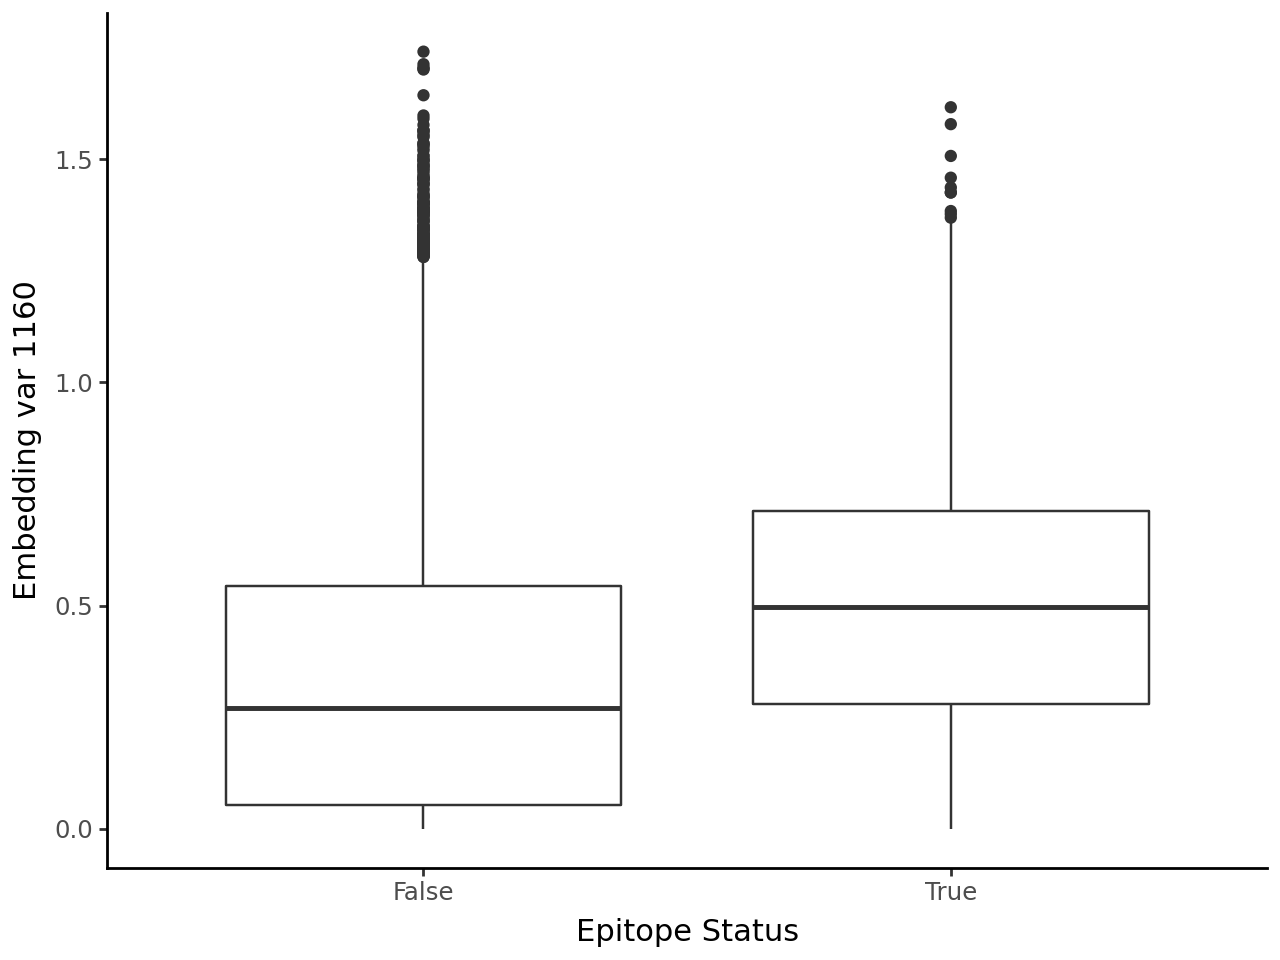

In [53]:
(
ggplot(bp3_res, aes(x = epitope_bools, y = rsa_vals))
+ geom_boxplot()
+ labs(
    x = "Epitope Status",
    y = "Embedding var 1160"
)
#+ geom_jitter()
)

In [57]:
# --- BP3 CV Evaluation ---

agg_features = [
    #"emb_1280",
    #"emb_1160",
    "emb_234",
    #"rsa_vals"
]

train_df = bp3_res.to_pandas()
X_df = train_df[agg_features]
y_df = train_df["epitope_bools"]

X = X_df.values
y = y_df.values

n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=1)

train_auc_scores = []
test_auc_scores = []


print("--- Cross-Validation Fold Details ---")
for fold, (train_index, test_index) in enumerate(cv.split(X, y)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # --- Choose Classifier ---

    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    scale_pos_weight_value = neg_count / pos_count if pos_count > 0 else 1

    clf = LogisticRegression(class_weight="balanced")
    clf.fit(X_train, y_train)

    # --- Training AUC Calculation ---
    y_train_proba = clf.predict_proba(X_train)[:, 1]
    train_auc = roc_auc_score(y_train, y_train_proba)
    train_auc_scores.append(train_auc)

    # --- Test AUC Calculation ---
    y_test_proba = clf.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_test_proba)
    test_auc_scores.append(test_auc)

    print(f"Fold {fold+1}: Train AUC = {train_auc:.4f}, Test AUC = {test_auc:.4f}")

# Mean ROC data
mean_auc_test = np.mean(test_auc_scores)
std_auc_test = np.std(test_auc_scores)

# --- Overfitting Check Section ---
print("\n--- Overfitting Check ---")
mean_train_auc = np.mean(train_auc_scores)
std_train_auc = np.std(train_auc_scores)

print(
    f"Average Training AUC across folds: {mean_train_auc:.4f} (+/- {std_train_auc:.4f})"
)
print(
    f"Average Test (Validation) AUC across folds: {mean_auc_test:.4f} (+/- {std_auc_test:.4f})"
)

--- Cross-Validation Fold Details ---
Fold 1: Train AUC = 0.6385, Test AUC = 0.6482
Fold 2: Train AUC = 0.6405, Test AUC = 0.6400
Fold 3: Train AUC = 0.6416, Test AUC = 0.6355
Fold 4: Train AUC = 0.6409, Test AUC = 0.6383
Fold 5: Train AUC = 0.6405, Test AUC = 0.6399

--- Overfitting Check ---
Average Training AUC across folds: 0.6404 (+/- 0.0010)
Average Test (Validation) AUC across folds: 0.6404 (+/- 0.0042)
